In [1]:
from pathlib import Path
from typing import Literal

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rc, rcParams
from matplotlib.ticker import AutoMinorLocator

from __future__ import annotations # for python <3.10 

# just to make the cells appear wider: comment these lines if needed. 
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

rc("font", family="serif", weight="bold")
rc("text", usetex=True)
rcParams["text.latex.preamble"] = r"\usepackage{amsmath}" + "\n" + r"\boldmath"
rc("axes", linewidth=2)
rcParams.update({
    "xtick.major.size": 12, "ytick.major.size": 12,
    "xtick.minor.size": 8,  "ytick.minor.size": 8,
    "font.weight": "bold",
})

FONTSIZE = 24

# path to the restructured data directory
DATA_DIR = Path("../Data_Mandel_and_Broekgaarden_2026")

# figures are saved here (created automatically if it doesn't exist)
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

gray_color = 'darkgrey'


/var/folders/07/v05tmc2s6p1f8qvmc216wrh80000gn/T/ipykernel_15760/2308444911.py:15: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [4]:
! ls ../Data_Mandel_and_Broekgaarden_2026/

CHE.csv
COC_rates_supplementary_material.pdf
example_relationships.csv
flybys.csv
globular-clusters.csv
individual_extracted_data
interactive_plots
isolated-binary-evolution_relationships.csv
isolated-binary-evolution.csv
nuclear-clusters.csv
observations-GWs.csv
observations-kilonovae.csv
observations-pulsars.csv
observations-sGRBs.csv
population-III.csv
primordial.csv
triples.csv
young-stellar-clusters.csv


In [14]:
import re
from typing import Optional, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import LogLocator, NullFormatter


# ── helpers ──────────────────────────────────────────────────────────────────

# Map the parameter column value(s) that identify alpha_CE rows
ALPHA_FAMILIES = {
    "common envelope efficiency (alpha_CE)",
    "CE efficiency & binding energy (alpha & lambda)",
    "CE efficiency alpha",
    "alpha_CE",
}

DCO_TYPES   = ["BH-BH", "NS-BH", "NS-NS"]
DCO_COLORS  = {"BH-BH": "#4C72B0", "NS-BH": "#55A868", "NS-NS": "#C44E52"}
DCO_MARKERS = {"BH-BH": "o",        "NS-BH": "s",       "NS-NS": "^"}

# Studies that are known to vary ONLY alpha (not other CE params simultaneously).
# Extend this list as you encode more papers.
ALPHA_ONLY_STUDIES = None   # None = include all studies in alpha families

# ── column normalisation ──────────────────────────────────────────────────────

def _normalise(df: pd.DataFrame) -> pd.DataFrame:
    """Rename/normalise common column spelling variants."""
    df = df.copy()

    # DCO type column
    for cand in ("compact_object_type", "DCO_type", "dco_type", "type"):
        if cand in df.columns:
            df = df.rename(columns={cand: "dco"})
            break

    # Normalise DCO values
    if "dco" in df.columns:
        df["dco"] = (
            df["dco"]
            .str.strip()
            .replace({"BNS": "NS-NS", "BHNS": "NS-BH", "BBH": "BH-BH",
                      "BH-NS": "NS-BH", "NS_NS": "NS-NS", "BH_BH": "BH-BH",
                      "NS_BH": "NS-BH"})
        )

    # Rate columns
    for cand in ("central_rate_Gpc3yr", "rate_Gpc3yr", "rate"):
        if cand in df.columns:
            df = df.rename(columns={cand: "rate"})
            break
    # If separate lower/upper exist but no single rate col, use the geometric mean
    if "rate" not in df.columns:
        lo = next((c for c in ("lower_rate_Gpc3yr", "from_rate_Gpc3yr") if c in df.columns), None)
        hi = next((c for c in ("upper_rate_Gpc3yr", "to_rate_Gpc3yr")   if c in df.columns), None)
        if lo and hi:
            df["rate"] = np.sqrt(df[lo].astype(float) * df[hi].astype(float))

    # Alpha column
    for cand in ("alpha_CE", "alpha", "parameter_value", "to_value", "value"):
        if cand in df.columns:
            df = df.rename(columns={cand: "alpha"})
            break

    # Model name / label
    for cand in ("model_name", "model", "label", "submodel"):
        if cand in df.columns:
            df = df.rename(columns={cand: "model_label"})
            break

    # Study name
    for cand in ("study_name", "study", "study_key", "reference"):
        if cand in df.columns:
            df = df.rename(columns={cand: "study_key"})
            break

    # Code name
    for cand in ("code", "code_name", "bps_code"):
        if cand in df.columns:
            df = df.rename(columns={cand: "code"})
            break

    return df


def _alpha_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only rows that belong to the CE efficiency family."""
    pf_col = next((c for c in ("parameter_family", "parameter") if c in df.columns), None)
    if pf_col is None:
        raise ValueError("No parameter_family or parameter column found.")

    mask = df[pf_col].str.strip().str.lower().isin(
        {s.lower() for s in ALPHA_FAMILIES}
    )
    out = df[mask].copy()
    print(f"[alpha_rows] {mask.sum()} rows matched out of {len(df)} total.")
    return out


def _extract_alpha_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """
    Try to extract a numeric alpha value.
    Priority: existing 'alpha' col → parse from model_label → parse from parameter col.
    """
    df = df.copy()

    def _parse(s):
        if pd.isna(s):
            return np.nan
        s = str(s)
        # look for patterns like alpha=0.5, alpha_CE=2, a=1, or standalone numbers
        m = re.search(r"(?:alpha[_\-ce]*\s*[=:]\s*|^)\s*([0-9]*\.?[0-9]+)", s, re.I)
        if m:
            return float(m.group(1))
        # bare number
        try:
            return float(s.strip())
        except ValueError:
            return np.nan

    if "alpha" not in df.columns:
        # Try to parse from model_label or parameter value columns
        for src in ("model_label", "parameter_value", "to_value", "label"):
            if src in df.columns:
                df["alpha"] = df[src].apply(_parse)
                if df["alpha"].notna().any():
                    break
        else:
            df["alpha"] = np.nan

    df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")
    return df


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Study overview: studies on Y-axis, alpha on X-axis
# ═══════════════════════════════════════════════════════════════════════════════

def plot_alpha_overview(
    df_raw: pd.DataFrame,
    figsize: Optional[tuple] = None,
    save_path: Optional[str] = None,
):
    """
    Horizontal "dot-strip" chart.

    Each study occupies one row on the Y-axis.  For every DCO type present in
    that study's alpha rows, a coloured line spans the alpha range explored,
    with scatter points at each distinct alpha value.  The BPS code name is
    shown at the right end of the line, and the study key at the left margin.
    """
    df = _normalise(df_raw)
    df = _alpha_rows(df)
    df = _extract_alpha_numeric(df)

    # Drop rows where alpha is unknown
    df = df[df["alpha"].notna()]

    if df.empty:
        print("No alpha rows found after filtering. Check parameter_family values.")
        return

    # ── build study list ──────────────────────────────────────────────────────
    study_col  = "study_key"  if "study_key"  in df.columns else None
    code_col   = "code"       if "code"       in df.columns else None

    if study_col is None:
        df["study_key"] = "unknown"
        study_col = "study_key"

    # Collect per-study info
    studies_order = (
        df.groupby(study_col)["alpha"]
        .apply(lambda x: x.max() - x.min())
        .sort_values(ascending=True)
        .index.tolist()
    )

    n_studies = len(studies_order)
    row_h = max(0.45, min(0.8, 15 / n_studies))
    if figsize is None:
        figsize = (11, max(4, n_studies * row_h + 1.5))

    fig, ax = plt.subplots(figsize=figsize)

    y_positions = {s: i for i, s in enumerate(studies_order)}

    # Track which DCO types we actually plot (for legend)
    plotted_dco = set()

    for study in studies_order:
        sub = df[df[study_col] == study]
        y   = y_positions[study]

        code_str = ""
        if code_col and sub[code_col].notna().any():
            code_str = sub[code_col].dropna().iloc[0]

        for dco in DCO_TYPES:
            ssub = sub[sub["dco"] == dco] if "dco" in sub.columns else pd.DataFrame()
            if ssub.empty:
                continue

            alphas = sorted(ssub["alpha"].dropna().unique())
            if not alphas:
                continue

            color  = DCO_COLORS[dco]
            marker = DCO_MARKERS[dco]
            plotted_dco.add(dco)

            # Offset slightly so overlapping DCO lines are distinguishable
            dco_offset = {"BH-BH": -0.08, "NS-BH": 0.0, "NS-NS": 0.08}[dco]
            yy = y + dco_offset

            # Line
            ax.plot(
                [min(alphas), max(alphas)], [yy, yy],
                color=color, lw=1.4, alpha=0.6, zorder=2
            )
            # Scatter
            ax.scatter(
                alphas, [yy] * len(alphas),
                color=color, marker=marker, s=40, zorder=3,
                edgecolors="white", linewidths=0.4
            )

            # Code label at right end (only once per study, using first DCO)
            if dco == DCO_TYPES[0] and code_str:
                ax.text(
                    max(alphas) + 0.05, yy + 0.10,
                    code_str,
                    fontsize=7, color="0.35", va="bottom", ha="left",
                    style="italic"
                )

    # ── Y-axis ────────────────────────────────────────────────────────────────
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(
        [s.replace("_", " ") for s in studies_order],
        fontsize=8
    )
    
    ax.set_ylim(-0.7, n_studies - 0.3)
   
    
    # ── X-axis ────────────────────────────────────────────────────────────────
    ax.set_xlabel(r"$\alpha_{\rm CE}$", fontsize=11)
    ax.set_title(
        r"Studies varying CE efficiency $\alpha_{\rm CE}$ — isolated binary evolution",
        fontsize=10, pad=8
    )
    ax.set_xscale("log")

    # ── legend ────────────────────────────────────────────────────────────────
    handles = [
        mlines.Line2D([], [], color=DCO_COLORS[d], marker=DCO_MARKERS[d],
                      markersize=6, label=d, linewidth=1.5)
        for d in DCO_TYPES if d in plotted_dco
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=8, framealpha=0.85)

    ax.grid(axis="x", ls="--", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Rate vs alpha per study, absolute + relative panels
# ═══════════════════════════════════════════════════════════════════════════════

def plot_rate_vs_alpha(
    df_raw: pd.DataFrame,
    study_keys: Optional[List[str]] = None,
    figsize_abs: Optional[tuple] = None,
    figsize_rel: Optional[tuple] = None,
    save_abs: Optional[str] = None,
    save_rel: Optional[str] = None,
    alpha_ref: float = 1.0,
    min_alpha_points: int = 2,
):
    """
    Two figures (absolute rate and rate relative to alpha_ref) each with
    three panels (BH-BH | NS-BH | NS-NS).

    Parameters
    ----------
    df_raw          : raw relationships DataFrame
    study_keys      : restrict to these study keys; None = all
    alpha_ref       : alpha value used as the normalisation reference (default 1)
    min_alpha_points: minimum distinct alpha values a study must have to appear
    """
    df = _normalise(df_raw)
    df = _alpha_rows(df)
    df = _extract_alpha_numeric(df)
    df = df[df["alpha"].notna()]

    if "rate" not in df.columns:
        print("No rate column found. Check column names (central_rate_Gpc3yr / from_rate_Gpc3yr etc.).")
        return

    if df.empty:
        print("No data to plot.")
        return

    if study_keys is not None:
        df = df[df["study_key"].isin(study_keys)]

    study_col = "study_key"

    # Keep only studies with enough alpha variety per DCO type
    qualified = []
    for study, sub in df.groupby(study_col):
        for dco in DCO_TYPES:
            ssub = sub[sub["dco"] == dco]
            if ssub["alpha"].nunique() >= min_alpha_points:
                qualified.append(study)
                break
    qualified = sorted(set(qualified))

    if not qualified:
        print(f"No studies have ≥{min_alpha_points} alpha values. "
              f"Try lowering min_alpha_points or check that alpha is parsed correctly.")
        return

    print(f"Plotting {len(qualified)} studies: {qualified}")

    # Build a colour cycle for studies
    cmap = plt.cm.get_cmap("tab20", len(qualified))
    study_color = {s: cmap(i) for i, s in enumerate(qualified)}
    study_ls    = {s: ls for s, ls in zip(
        qualified, ["-", "--", "-.", ":", "-", "--", "-.", ":"] * 10
    )}

    # ── helper: one figure ────────────────────────────────────────────────────
    def _make_figure(relative: bool, figsize, save_path):
        fig, axes = plt.subplots(
            1, 3,
            figsize=figsize or (14, 4.5),
            sharey=False,
            constrained_layout=True,
        )
        fig.suptitle(
            (r"Rate relative to $\alpha_{\rm CE}=$" + f"{alpha_ref}" if relative
             else r"Merger rate vs $\alpha_{\rm CE}$") +
            "  —  isolated binary evolution",
            fontsize=11, y=1.02
        )

        has_legend_handle = {}

        for ax, dco in zip(axes, DCO_TYPES):
            for study in qualified:
                sub = (
                    df[(df[study_col] == study) & (df["dco"] == dco)]
                    .dropna(subset=["alpha", "rate"])
                    .sort_values("alpha")
                )
                if sub.empty or sub["alpha"].nunique() < min_alpha_points:
                    continue

                # Aggregate: if multiple rows share the same alpha (e.g. lower/upper),
                # take the median as the "central" rate.
                grp = sub.groupby("alpha")["rate"].median().reset_index()

                xs = grp["alpha"].values
                ys = grp["rate"].values

                if relative:
                    # Find rate at alpha_ref (or interpolate / extrapolate)
                    if alpha_ref in xs:
                        ref_rate = ys[xs == alpha_ref][0]
                    else:
                        # linear interpolation in log-log space
                        log_xs = np.log(xs)
                        log_ys = np.log(np.clip(ys, 1e-10, None))
                        log_ref = np.interp(
                            np.log(alpha_ref), log_xs, log_ys,
                            left=log_ys[0], right=log_ys[-1]
                        )
                        ref_rate = np.exp(log_ref)

                    if ref_rate <= 0 or np.isnan(ref_rate):
                        continue
                    ys = ys / ref_rate

                code_str = ""
                if "code" in df.columns:
                    c = df[df[study_col] == study]["code"].dropna()
                    if not c.empty:
                        code_str = c.iloc[0]

                label_str = study.replace("_", " ")
                if code_str:
                    label_str = f"{code_str}  •  {label_str}"

                ax.plot(
                    xs, ys,
                    color=study_color[study],
                    ls=study_ls[study],
                    lw=1.8,
                    marker="o", markersize=5,
                    markeredgecolor="white", markeredgewidth=0.4,
                    label=label_str if study not in has_legend_handle else "_",
                    zorder=3,
                )
                has_legend_handle[study] = True

            # Axes formatting
            ax.set_title(dco, fontsize=10, color=DCO_COLORS[dco], fontweight="bold")
            ax.set_xlabel(r"$\alpha_{\rm CE}$", fontsize=10)

            if relative:
                ax.axhline(1.0, ls=":", color="0.6", lw=1, zorder=1)
                ax.set_ylabel(
                    r"Rate / Rate($\alpha_{\rm CE}=$" + f"{alpha_ref})",
                    fontsize=9
                ) if dco == DCO_TYPES[0] else None
                ax.set_yscale("log")
                ax.set_xscale("log")
            else:
                ax.set_ylabel(r"$\mathcal{R}$ [Gpc$^{-3}$ yr$^{-1}$]", fontsize=9) \
                    if dco == DCO_TYPES[0] else None
                ax.set_yscale("log")
                ax.set_xscale("log")
                ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
                ax.yaxis.set_minor_formatter(NullFormatter())

            ax.grid(ls="--", alpha=0.3)
            ax.spines[["top", "right"]].set_visible(False)

        # ── shared legend below figure ────────────────────────────────────────
        handles, labels = axes[0].get_legend_handles_labels()
        # collect from all axes
        for ax in axes[1:]:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels and ll != "_":
                    handles.append(hh)
                    labels.append(ll)

        if handles:
            fig.legend(
                handles, labels,
                loc="lower center",
                bbox_to_anchor=(0.5, -0.18),
                ncol=min(3, len(handles)),
                fontsize=8,
                framealpha=0.85,
                title="BPS code  •  study",
                title_fontsize=8,
            )

        if save_path:
            fig.savefig(save_path, dpi=180, bbox_inches="tight")
            print(f"Saved → {save_path}")
        plt.show()

    _make_figure(relative=False, figsize=figsize_abs, save_path=save_abs)
    _make_figure(relative=True,  figsize=figsize_rel, save_path=save_rel)

    
    
import sys

path = sys.argv[1] if len(sys.argv) > 1 else "isolated-binary-evolution_relationships.csv"



[alpha_rows] 625 rows matched out of 7408 total.
Saved → alpha_overview.png


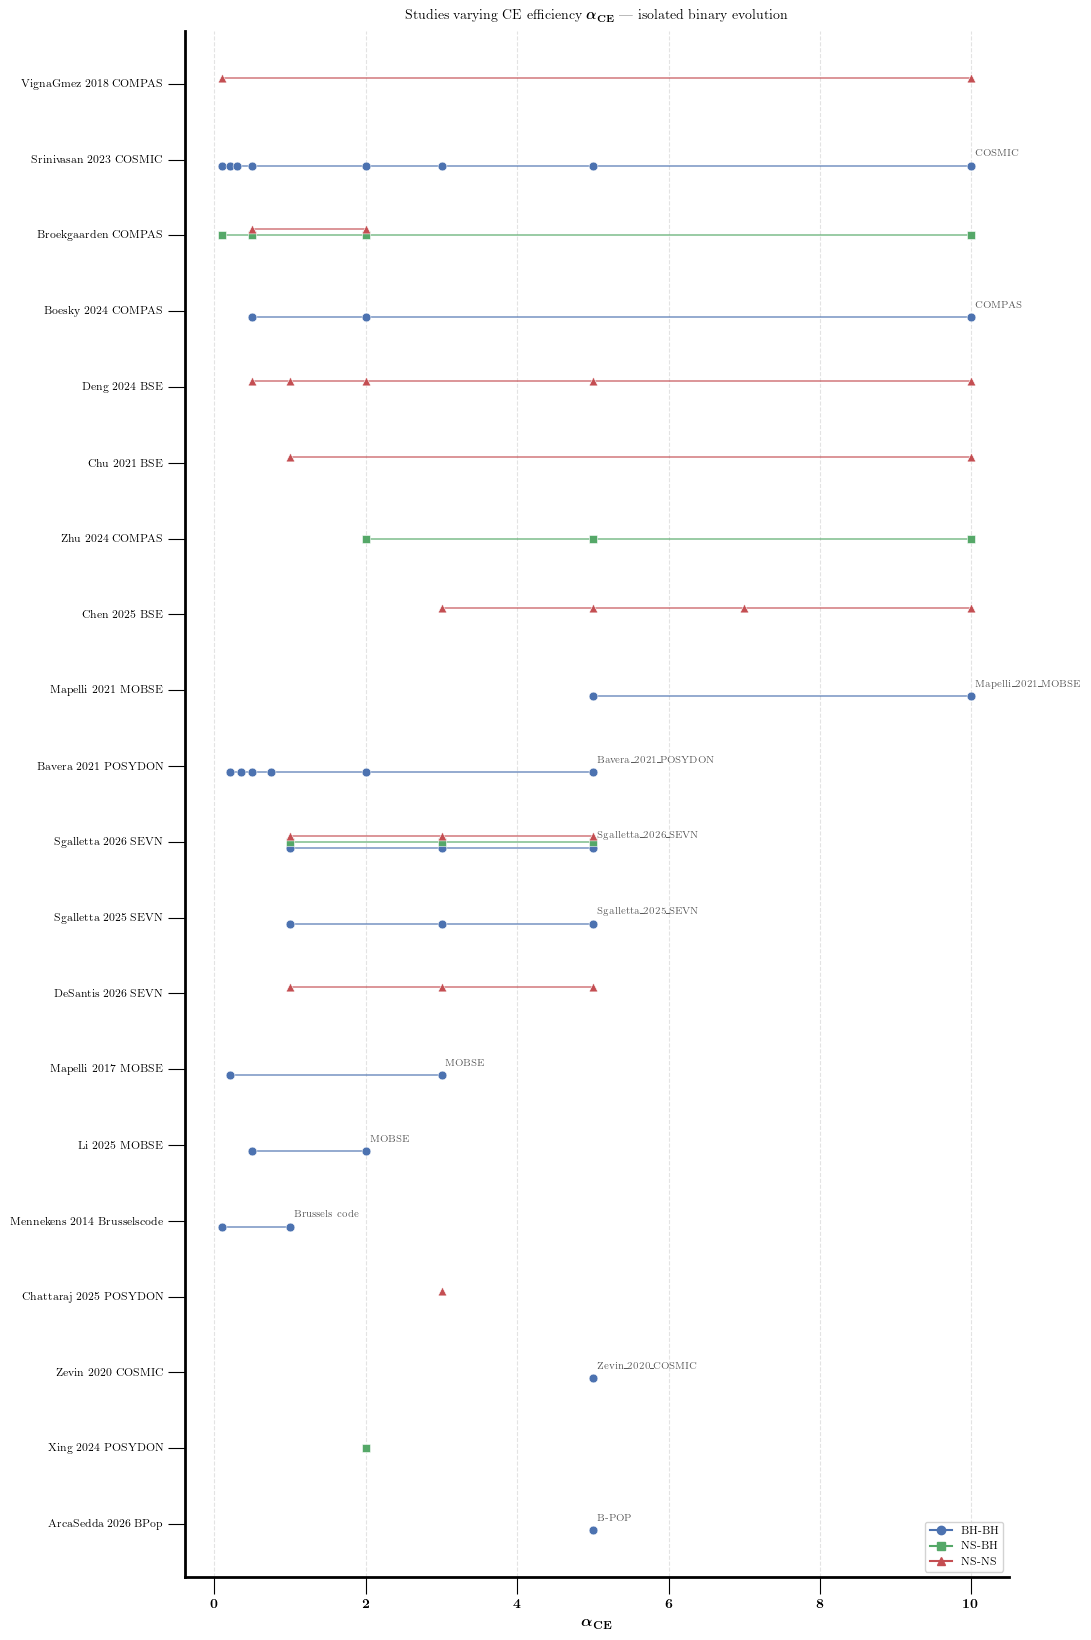

[alpha_rows] 625 rows matched out of 7408 total.
Plotting 16 studies: ['Bavera_2021_POSYDON', 'Boesky_2024_COMPAS', 'Broekgaarden_COMPAS', 'Chen_2025_BSE', 'Chu_2021_BSE', 'DeSantis_2026_SEVN', 'Deng_2024_BSE', 'Li_2025_MOBSE', 'Mapelli_2017_MOBSE', 'Mapelli_2021_MOBSE', 'Mennekens_2014_Brusselscode', 'Sgalletta_2025_SEVN', 'Sgalletta_2026_SEVN', 'Srinivasan_2023_COSMIC', 'VignaGmez_2018_COMPAS', 'Zhu_2024_COMPAS']
Saved → alpha_rate_abs.png


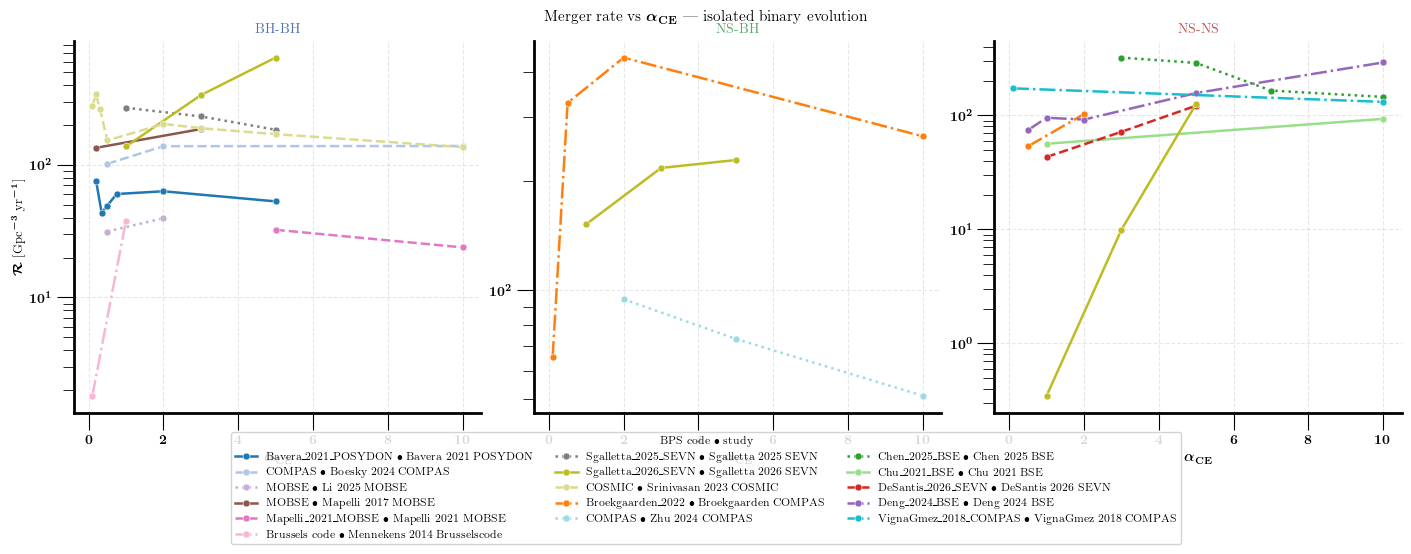

RuntimeError: latex was not able to process the following string:
b'Rate / Rate($\\\\alpha_{\\\\rm CE}$=1.0$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp_ldg5vgl 011157aa02343ee5531059c4f4c1cb0d.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025/Homebrew) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./011157aa02343ee5531059c4f4c1cb0d.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/articl
e.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/size10
.clo))
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/type1cm/typ
e1cm.sty)
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/cm-super/ty
pe1ec.sty
(/opt/homebrew/Cellar/texlive/202

Error in callback <function _draw_all_if_interactive at 0x10f07d670> (for post_execute):


RuntimeError: latex was not able to process the following string:
b'Rate / Rate($\\\\alpha_{\\\\rm CE}$=1.0$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp47onnmcs 011157aa02343ee5531059c4f4c1cb0d.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025/Homebrew) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./011157aa02343ee5531059c4f4c1cb0d.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/articl
e.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/size10
.clo))
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/type1cm/typ
e1cm.sty)
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/cm-super/ty
pe1ec.sty
(/opt/homebrew/Cellar/texlive/202

RuntimeError: latex was not able to process the following string:
b'Rate / Rate($\\\\alpha_{\\\\rm CE}$=1.0$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmphv1m_u8j 011157aa02343ee5531059c4f4c1cb0d.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025/Homebrew) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./011157aa02343ee5531059c4f4c1cb0d.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/articl
e.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class

(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/base/size10
.clo))
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/type1cm/typ
e1cm.sty)
(/opt/homebrew/Cellar/texlive/20250308_1/share/texmf-dist/tex/latex/cm-super/ty
pe1ec.sty
(/opt/homebrew/Cellar/texlive/202

<Figure size 1400x450 with 3 Axes>

In [15]:
import pandas as pd
from plot_alpha_ce import plot_alpha_overview, plot_rate_vs_alpha

df = pd.read_csv("../Data_Mandel_and_Broekgaarden_2026/isolated-binary-evolution_relationships.csv")

# Plot 1 — study overview
plot_alpha_overview(df, save_path="alpha_overview.png")

# Plot 2 — rate vs alpha (absolute + relative panels)
plot_rate_vs_alpha(df, alpha_ref=1.0,
                   save_abs="alpha_rate_abs.png",
                   save_rel="alpha_rate_rel.png")